# Does Female Representation in Governments affect GDP Growth Rate?

A study of whether female representation in government, both in parliament and at ministerial levels, is associated with a country's annual GDP growth rate.

## Section 1: Hypothesis, Analysis Goal

#### Hypothesis/analysis goal (Ask)

As nations across the world start to implement policies to improve gender equality on the governmental front, it would be interesting to see if this trend would affect the holistic standard of living of a country (referring to economic robustness, levels of education etc) of countries. This study serves to find out if there is a correlation between governmental female representation and the economic growth of the nation. Governmental female representation will be measured by the proportion of females in Parliament, as well as the proportion of females in ministerial level positions in a particular year. Holistic standard of living as captured by Human Development Index's growth YoY. 


## Section 2: Data Sources and Requirements

#### Data source identification and exploration (Prepare)

To investigate the relationship between female representation in government and the holistic standard of living of a country, we need data about:

- Human Developmen Index growth rates
- Female Representation in Parliament

**List of considered sources.** In the following, we outline several sources we considered and explored and justify the final source selection (marked with an *), in particular based on concepts discussed in class.

**Global Annual Human Development Index (HDI)**
  * [Human Development Data (DS1)](https://data.humdata.org/dataset/human-development-data)
   
**Female Representation in Parliament Data**
  * [Proportion of Seats Held by Women in National Parliaments (%) (DS2)](https://genderdata.worldbank.org/en/indicator/sg-gen-parl-zs)
  * [Proportion of Women in Ministerial Level Positions (%) (DS3)](https://genderdata.worldbank.org/en/indicator/sg-gen-mnst-zs)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. DS1: UNDP Human Development Report 2021/22 – Composite Indices

**Description**

The UNDP Human Development Report dataset, comprising of the Human Development Index(HDI) spans across geographically across the countries that provides a geographical coverage that is wide enough to draw representative conclusions and temporally from 1990 to 2021, giving us 32 years of longitudinal data. For our analysis, the temporal range was standardised to start from 2005 to ensure alignment with the female representation indicators and prevent data sparsity issues.

The HDI is a composite statistic measuring average achievement across three fundamental dimensions of human development: a long and healthy life (life expectancy), access to knowledge (education), and a decent standard of living (GNI per capita). As a holistic measure of national well-being, it serves as a meaningful indicator of economic and social development alongside traditional GDP measures.

The dataset consists of the following columns:
- iso3: 3-letter ISO country code (e.g. AFG, ALB, AGO)
- country: Full country name (e.g. Afghanistan, Albania, Angola)
- hdicode: UNDP HDI development tier: Low, Medium, High, or Very High
- region: Geographic region code: SA (South Asia), SSA (Sub-Saharan Africa), ECA (Europe & Central Asia), AS (Arab States), LAC (Latin America & Caribbean), EAP (East Asia & Pacific)
- hdi_rank_2021: Country's global HDI ranking as of 2021 (integer, e.g. 180 for Afghanistan)
- hdi_YYYY: HDI value for the year YYYY (1991-2021)


In [2]:

hdr_file = r'HDR21-22_Composite_indices_complete_time_series.csv'

# 1. Load the HDR dataset
df_hdr_wide = pd.read_csv(hdr_file, encoding='latin1')

# 2. Select metadata columns and HDI year columns only
meta_cols = ['iso3', 'country', 'hdicode', 'region']
hdi_year_cols = [c for c in df_hdr_wide.columns if c.startswith('hdi_') and c[4:].isdigit()]
df_hdr_subset = df_hdr_wide[meta_cols + hdi_year_cols]

# 3. Remove aggregates: rows with null hdicode represent regional/global groups
df_countries_hdr = df_hdr_subset.dropna(subset=['hdicode'])

# 4. Transform: Melt from 'Wide' to 'Long'
df_hdr_long = pd.melt(
    df_countries_hdr,
    id_vars=meta_cols,
    var_name='Year',
    value_name='HDI'
)

# Extract numeric year from column name (e.g. 'hdi_2005' -> 2005)
df_hdr_long['Year'] = df_hdr_long['Year'].str.extract(r'(\d+)').astype(int)

# 5. Final Cleaning & Alignment (2005 onwards)
df_hdr_final = df_hdr_long[df_hdr_long['Year'] >= 2005].reset_index(drop=True)

# 6. Display
df_hdr_final[['country', 'Year', 'HDI', 'region', 'hdicode']]

,country,Year,HDI,region,hdicode
0,Afghanistan,2005,0.400,SA,Low
1,Angola,2005,0.447,SSA,Medium
2,Albania,2005,0.711,ECA,High
3,Andorra,2005,0.833,NaN,Very High
4,United Arab Emirates,2005,0.822,AS,Very High
...,...,...,...,...,...
3242,Samoa,2021,0.707,EAP,High
3243,Yemen,2021,0.455,AS,Low
3244,South Africa,2021,0.713,SSA,High
3245,Zambia,2021,0.565,SSA,Medium


Through our data cleaning, we have differentiated sovereign nations from regional aggregates to ensure statistical accuracy and avoid double-counting. The `hdicode` and `region` metadata are already embedded in the dataset, offering sufficient granularity to control for geographic and development-stage differences in our analysis. 

The annual granularity is appropriate for identifying the longitudinal relationship between political shifts and human development outcomes. For our analytics tasks, we need to ensure that we sufficiently cover a variety of development contexts, specifically ensuring representation across Low and Medium HDI nations to mitigate the reporting bias often found in highly developed datasets.

#### Profiling completeness by HDI group (2021)

In [3]:
# Profiling: Count non-null values per HDI Group for the year 2021
profile_2021 = df_hdr_final[df_hdr_final['Year'] == 2021].groupby('hdicode')['HDI'].count()
print("Data Completeness for 2021 by HDI Group:\n", profile_2021)

Data Completeness for 2021 by HDI Group:
 hdicode
High         49
Low          32
Medium       44
Very High    66
Name: HDI, dtype: int64


To ensure the dataset's reliability before conducting further analysis, we profiled the results for 2021. We selected 2021 as the baseline year as it is the most recent year with the highest data completeness in the HDR dataset. By grouping HDI values by development level, we verify the successful transformation of our dataset and assess the representativeness of our sample across all four HDI tiers, identifying any potential biases toward higher-income nations.

#### Exploring Countries Covered in the Dataset

In [26]:
# List the distinct countries in the dataset to verify granularity
distinct_countries = df_hdr_final['country'].unique()
print(f"Total Unique Nations: {len(distinct_countries)}")
print(distinct_countries)

Total Unique Nations: 191
['Afghanistan' 'Angola' 'Albania' 'Andorra' 'United Arab Emirates'
 'Argentina' 'Armenia' 'Antigua and Barbuda' 'Australia' 'Austria'
 'Azerbaijan' 'Burundi' 'Belgium' 'Benin' 'Burkina Faso' 'Bangladesh'
 'Bulgaria' 'Bahrain' 'Bahamas' 'Bosnia and Herzegovina' 'Belarus'
 'Belize' 'Bolivia (Plurinational State of)' 'Brazil' 'Barbados'
 'Brunei Darussalam' 'Bhutan' 'Botswana' 'Central African Republic'
 'Canada' 'Switzerland' 'Chile' 'China' "CÃ´te d'Ivoire" 'Cameroon'
 'Congo (Democratic Republic of the)' 'Congo' 'Colombia' 'Comoros'
 'Cabo Verde' 'Costa Rica' 'Cuba' 'Cyprus' 'Czechia' 'Germany' 'Djibouti'
 'Dominica' 'Denmark' 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt'
 'Eritrea' 'Spain' 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'France'
 'Micronesia (Federated States of)' 'Gabon' 'United Kingdom' 'Georgia'
 'Ghana' 'Guinea' 'Gambia' 'Guinea-Bissau' 'Equatorial Guinea' 'Greece'
 'Grenada' 'Guatemala' 'Guyana' 'Hong Kong, China (SAR)' 'Honduras'
 'Croatia' 'H

While the dataset covers 191 sovereign nations across diverse geographies and development levels, it lacks sub-national granularity for federal states. For example, the human development nuances of self-governing US states or German Bundesländer are aggregated into a single national HDI figure. This represents a limitation for our later comparison with female representation, as different governance systems distribute legislative power differently. Additionally, the dataset covers up to 2021 only, which may slightly limit alignment with the most recent female representation indicators.

#### Exploring HDI Group Representations

In [27]:
# List the distinct HDI Groups to verify categorical granularity
distinct_hdi_groups = df_hdr_final['hdicode'].unique()
print(distinct_hdi_groups)

['Low' 'Medium' 'High' 'Very High']


A wide range of human development levels were covered, from Low to Very High HDI. Thus, the dataset is representative of nations operating at various stages of development. This alleviates the risk of focusing only on highly developed economies and allows our analysis to generalise across different global contexts.

#### Data quality considerations

We highlight the following quality criteria that we assessed (among others) to determine the suitability of the dataset for our task:

- *Completeness*: The dataset satisfies our technical requirements for longitudinal analysis as it offers over 30 years of annual HDI data globally. Our profiling confirmed that the data provides sufficient breadth (covering Low, Medium, High, and Very High HDI countries across all major geographic regions) and depth (consistent annual reporting from 1990 to 2021, with full coverage for 191 nations in 2021). These factors ensure that our findings will be statistically representative across diverse development contexts.

- *Interpretability*: The interpretability of this dataset is exceptionally high. The HDI is a well-established composite index with clear, standardised methodology defined by the UNDP. The inclusion of `hdicode` and `region` metadata provides clear categorical attributes for diagnostic analysis, allowing us to segment results by development level without ambiguity.

- *Reputation*: Unlike scraped or community-sourced data, this dataset has a high reputation as it is produced and maintained by the United Nations Development Programme (UNDP). The provenance is well-documented, with established methodologies for data collection from national statistical bureaus and international organisations.

Although the temporal coverage ends in 2021 and the aggregation of sub-national data in federal systems could introduce minor biases, the comprehensiveness of this dataset makes it the most suitable choice for our research task.

#### Conclusion for UNDP HDR 2021/22 Composite Indices Dataset

We find the dataset suited for our analysis with the following caveats, which we will take into account during data preparation and analysis:
- The temporal coverage ends in 2021, which may limit full alignment with female representation data extending to 2024. Analysis will be restricted to the overlapping period (2005–2021).
- The aggregation of sub-national data into national HDI averages may introduce minor biases. In federal systems where human development outcomes are highly decentralised, national-level HDI may not fully capture the leadership dynamics at the state level. While cross-validating with sub-national datasets is an option to mitigate this, it is not further considered within the scope of this project.

## 4. DS2: Proportion of seats held by women in national parliaments (%)

**Description.** We downloaded the CSV file from Kaggle on 30/01/2026 from the World Bank Group website. The data is organised year by year, with 4 columns of Economy Code, Country Name, Proportion of Seats Held by Women in National Parliaments, and Year. All columns are necessary and will be used in our analysis. The World Bank Group defines the proportion of seats held by women in national parliaments is the number of seats held by women members in single or lower chambers of national parliaments, expressed as a percentage of all occupied seats; it is derived by dividing the total number of seats occupied by women by the total number of seats in parliament.

In [ ]:
# prompt: list column labels from the CSV file sample_data/matches_1930_2022.csv

# Read the CSV file into a DataFrame
table = pd.read_csv(r"proportion-of-seats-held-by-women-in-national-parliaments/Proportion of seats held by women in national parliaments (%).csv")

# Get the column labels (header)
column_labels = table.columns.tolist()

# Print the column labels
print(column_labels)

['Indicator Name', 'Indicator Code', 'Country Name', 'Country Code', 'Year', 'Value', 'Disaggregation']


#### Profiling geographic coverage

We perform some data profiling on the data to better understand the countries it covers.

In [29]:
# Showing the number of unique countries
unique_entities = table['Country Code'].unique()
print(unique_entities)
print("Number of Total Entities: "+ str(len(unique_entities)))

['AFE' 'AFW' 'ARB' 'CSS' 'CEB' 'EAR' 'EAS' 'EAP' 'TEA' 'EMU' 'ECS' 'ECA'
 'TEC' 'EUU' 'FCS' 'HPC' 'HIC' 'IBD' 'IBT' 'IDB' 'IDX' 'IDA' 'LTE' 'LCN'
 'LAC' 'TLA' 'LDC' 'LMY' 'LIC' 'LMC' 'MEA' 'MNA' 'TMN' 'MIC' 'NAC' 'OED'
 'OSS' 'PSS' 'PST' 'PRE' 'SST' 'SAS' 'TSA' 'SSF' 'SSA' 'TSS' 'UMC' 'WLD'
 'AFG' 'ALB' 'DZA' 'AND' 'AGO' 'ATG' 'ARG' 'ARM' 'AUS' 'AUT' 'AZE' 'BHS'
 'BHR' 'BGD' 'BRB' 'BLR' 'BEL' 'BLZ' 'BEN' 'BTN' 'BOL' 'BIH' 'BWA' 'BRA'
 'BRN' 'BGR' 'BFA' 'BDI' 'CPV' 'KHM' 'CMR' 'CAN' 'CAF' 'TCD' 'CHL' 'CHN'
 'COL' 'COM' 'COD' 'COG' 'CRI' 'CIV' 'HRV' 'CUB' 'CYP' 'CZE' 'DNK' 'DJI'
 'DMA' 'DOM' 'ECU' 'EGY' 'SLV' 'GNQ' 'ERI' 'EST' 'SWZ' 'ETH' 'FJI' 'FIN'
 'FRA' 'GAB' 'GMB' 'GEO' 'DEU' 'GHA' 'GRC' 'GRD' 'GTM' 'GIN' 'GNB' 'GUY'
 'HTI' 'HND' 'HUN' 'ISL' 'IND' 'IDN' 'IRN' 'IRQ' 'IRL' 'ISR' 'ITA' 'JAM'
 'JPN' 'JOR' 'KAZ' 'KEN' 'KIR' 'PRK' 'KOR' 'KWT' 'KGZ' 'LAO' 'LVA' 'LBN'
 'LSO' 'LBR' 'LBY' 'LIE' 'LTU' 'LUX' 'MDG' 'MWI' 'MYS' 'MDV' 'MLI' 'MLT'
 'MHL' 'MRT' 'MUS' 'MEX' 'FSM' 'MDA' 'MCO' 'MNG' 'M

Looking at the above statistics and value distributions, we see that the countries that this dataset covers is comprehensive, a total of 217 economies. This covers a broad geographical scope, ensuring our analysis captures diverse contexts, from developing nations to emerging markets and developing economies, making our findings more generalizable across all types of economies.

However, we do have to take not that not all economies are sovereign nations under the UN, since there is only a total of 195 registered. There are some terrorities and dependencies:

- British Virgin Islands, American Samoa, Guam, Puerto Rico, U.S. Virgin Islands (U.S. territories)
- Bermuda, Cayman Islands, Gibraltar (British territories) This might count in some countries being double counted and needs to be dealt with during data preprocessing.

Also, the temporal depth of this dataset makes it a suitable choice as well, spanning 18 years from 1997 to 2024. The coverage across time and space makes it comprehensive enough for our analysis.

#### Quality considerations

Using the criteria established above:
- **Completeness**: The dataset satisfies our technical requirements for longitudinal analysis as it offers 18 years of annual GDP growth globally. Our profiling also confirmed that the data provides sufficient breadth of countries in terms of economy type, geographical location and other aspects.

- **Interpretability**: The interpretability of this dataset is very high. The indicator (Proportion of Seats Held by Females in National Parliaments) is clear and requires no further clarification

- **Reputation**: This dataset was found in the World Bank Group website and has a high reputation, as well as good documentation detailing how key metrics were calculated.

#### Conclusions for the World Bank Group dataset

By itself, the World Bank Group dataset is ideal for our analytical goal, mainly due to its coverage of time periods and geographies. We will therefore use this dataset for our project.

## 5. DS3: Proportion of women in ministerial level positions (%)
**Description.** Women in ministerial level positions is the proportion of women in ministerial or equivalent positions (including deputy prime ministers) in the government. Prime Ministers/Heads of Government are included when they hold ministerial portfolios. Vice-Presidents and heads of governmental or public agencies are excluded.

The dataset is retrieved from World Bank Group consisting of the following data:

- **indicator name**:plain-English description of what is being measured, which in this case is the percentage of women in ministeral position.

- **indicator code**: unique ID (usually a string of letters and numbers) used by database systems to identify the percentage of women in ministeral position metric.

- **country name**: full name of the country, territory, or region.

- **country code**:3-letter abbreviation (ISO code) for the country, territory, or region.

- **Year**: calendar year the data was collected.

- **value**: actual percentage of women in ministeral position.

**Note that country include aggregates in terms of region (eg. Africa Western and Central) which may result in double counting**

**Viewing.** We take a look at this dataset after removing irrelevant columns such as indicator name, indicator code and disaggregation (which has no values logged in CSV).

In [ ]:
# Read the CSV file into a DataFrame
df_proportion = pd.read_csv(r"proportion-of-women-in-ministerial-level-positions (1)/Proportion of women in ministerial level positions (%).csv")

# Remove the columns not needed
cols_to_remove = ['Indicator Name', 'Indicator Code', 'Disaggregation']
df_proportion = df_proportion.drop(columns=cols_to_remove)

# Convert 'Year' to datetime
df_proportion['Year'] = pd.to_datetime(df_proportion['Year'], format='%Y')

# Look at the cleaned data
df_proportion.head(50)

,Country Name,Country Code,Year,Value
0,Africa Eastern and Southern,AFE,2024-01-01,26.455
1,Africa Eastern and Southern,AFE,2023-01-01,26.408
2,Africa Eastern and Southern,AFE,2022-01-01,29.061
3,Africa Eastern and Southern,AFE,2020-01-01,29.421
4,Africa Eastern and Southern,AFE,2019-01-01,26.710
5,Africa Eastern and Southern,AFE,2018-01-01,28.811
6,Africa Eastern and Southern,AFE,2016-01-01,21.160
7,Africa Eastern and Southern,AFE,2015-01-01,21.726
8,Africa Eastern and Southern,AFE,2014-01-01,23.528
9,Africa Eastern and Southern,AFE,2012-01-01,21.963


#### Profiling date coverage

Verify the date range of the dataset to so that it can be altered later on to correctly overlap with the date range of Annual GDP and Proportion of Seats in Parliament datasets.

In [31]:
# Check the earliest and latest dates in the dataset
min_date = df_proportion['Year'].min()
max_date = df_proportion['Year'].max()

print(f"Data starts from: {min_date}")
print(f"Data ends at: {max_date}")

Data starts from: 2005-01-01 00:00:00
Data ends at: 2024-01-01 00:00:00


Data starts from: 2005-01-01 00:00:00
Data ends at: 2024-01-01 00:00:00
Profiling geographical coverage

Evaluate the total number of unique countries and regions to identify potential double-counting caused by the inclusion of aggregate regional data which will be delt with during data cleaning later.

In [32]:
# Count the number of unique Country Codes
unique_count = df_proportion['Country Code'].nunique()

# Get a list of all unique Country Names to see the Regions vs Countries
unique_entities = df_proportion['Country Name'].unique()

print(f"Total unique entities (Countries + Regions): {unique_count}")
print("-" * 30)
print("List of entities:")
print(unique_entities)

Total unique entities (Countries + Regions): 241
------------------------------
List of entities:
['Africa Eastern and Southern' 'Africa Western and Central' 'Arab World'
 'Caribbean small states' 'Central Europe and the Baltics'
 'Early-demographic dividend' 'East Asia & Pacific'
 'East Asia & Pacific (excluding high income)'
 'East Asia & Pacific (IDA & IBRD)' 'Euro area' 'Europe & Central Asia'
 'Europe & Central Asia (excluding high income)'
 'Europe & Central Asia (IDA & IBRD)' 'European Union'
 'Fragile and conflict affected situations'
 'Heavily indebted poor countries (HIPC)' 'High income' 'IBRD only'
 'IDA & IBRD total' 'IDA blend' 'IDA only' 'IDA total'
 'Late-demographic dividend' 'Latin America & Caribbean'
 'Latin America & Caribbean (excluding high income)'
 'Latin America & Caribbean (IDA & IBRD)'
 'Least developed countries: UN classification' 'Low & middle income'
 'Low income' 'Lower middle income'
 'Middle East, North Africa, Afghanistan & Pakistan'
 'Middle East & N

The exploration shows 245 number of unique countries and regions. Given that there are 195 independent countries in the world, this indicates the presence of 50 regional data which overlaps with the country data, for example:
- the region Africa Eastern and Southern
- region includes other African countries

This can result in double counting and skewing of results.

**Profiling of completeness of data**

Validate that a percentage data exists for each country/region for each year

In [33]:
# 1. Filter for the specific timeframe (2005 to 2024)
mask = (df_proportion['Year'] >= '2005-01-01') & (df_proportion['Year'] <= '2024-01-01')
df_filtered = df_proportion.loc[mask]

# 2. Group by Country Code and count the entries in the 'Value' column
# .count() only counts non-null (not empty) values
data_counts = df_filtered.groupby('Country Code')['Value'].count().reset_index()

# 3. Rename columns for clarity
data_counts.columns = ['Country Code', 'Data_Points_Count']

# 4. Sort by the count so you can see who has the most/least data
data_counts = data_counts.sort_values(by='Data_Points_Count', ascending=False)

# Display the result
print(data_counts.head(20)) # Show top 20

   Country Code  Data_Points_Count
0           AFE                 13
2           AFW                 13
3           AGO                 13
4           ALB                 13
5           AND                 13
7           ARE                 13
6           ARB                 13
8           ARG                 13
9           ARM                 13
14          BDI                 13
10          ATG                 13
11          AUS                 13
12          AUT                 13
16          BEN                 13
15          BEL                 13
18          BGD                 13
17          BFA                 13
47          CYP                 13
43          CPV                 13
19          BGR                 13


Data Frequency Limitation: While the study covers a 20-year period (2005-2024), the dataset contains only 13 observations per entity, confirming that reporting is non-annual.

Data is recorded for select years: 2024, 2023, 2022, 2020, 2019, 2018, 2016, 2015, 2014, 2012, 2010, 2008, and 2005. This irregular reporting schedule presents a significant challenge for downstream analysis, as the lack of a continuous time series prevents standard Year-over-Year (YoY) growth comparisons.

In [34]:
# 1. Filter for the specific timeframe (2005 to 2024)
mask = (df_proportion['Year'] >= '2005-01-01') & (df_proportion['Year'] <= '2024-01-01')
df_filtered = df_proportion.loc[mask]

# 2. Group by Country Code and count the non-null entries
data_counts = df_filtered.groupby('Country Code')['Value'].count().reset_index()

# 3. Rename columns
data_counts.columns = ['Country Code', 'Data_Points_Count']

# --- NEW STEP: FILTER AND COUNT ---

# 4. Filter for ISO codes where the count is NOT 13
not_13_df = data_counts[data_counts['Data_Points_Count'] != 13]

# 5. Get the total count of these ISO codes
total_not_13 = len(not_13_df)

# Display results
print(f"Number of ISO codes that do not have 13 data points: {total_not_13}")
print("-" * 30)
print("Top rows of entities without 13 data points:")
display(not_13_df.head())

Number of ISO codes that do not have 13 data points: 43
------------------------------
Top rows of entities without 13 data points:


,Country Code,Data_Points_Count
1,AFG,10
13,AZE,12
24,BLZ,12
30,BWA,12
31,CAF,12


The above are the regions/countries that have missing datasets which need to be noted when analysing later on.

##### Quality considerations

**Completeness**: The dataset satisfies our technical requirements for longitudinal analysis by providing a broad historical range from 2005 to 2024. While the ministerial data follows an irregular reporting schedule (13 observations over 20 years), it offers sufficient breadth across geographical regions and income levels to facilitate a comparative global study.

**Interpretability**: The interpretability of this dataset is very high. The primary indicatorâ€”Proportion of Women in Ministerial Level Positions (%)â€”is clearly defined as the percentage of cabinet members or ministers who are female, requiring no further technical clarification for analysis.

**Reputation**: This dataset is sourced from the World Bank Gender Data Portal and carries a high reputation for accuracy. It is supported by robust documentation and standardized "Country Codes" (ISO), ensuring that the methodology for data collection and aggregation is transparent and reliable for academic or professional research.

##### Conclusion for the World Bank Group Data

We will take this dataset into account for more accurate reflection of women's involvement in politics with careful consideration when cleaning the data

## Section 6: Structuring Data — Dropping Irrelevant Rows

Currently, each dataset contains ISO codes that represent both individual countries and regional/income-group aggregates (e.g. `WLD`, `ECA`, `HIC`). Including these aggregates would cause double-counting and skew any analysis. To standardise granularity across all three datasets, we filter each one to retain only rows whose ISO3 code is a verified sovereign country according to the ISO 3166-1 standard, using the `pycountry` library as the canonical reference.

In [35]:
import pycountry

valid_iso3 = {c.alpha_3 for c in pycountry.countries}
print(f"Canonical ISO3 reference (pycountry ISO 3166-1): {len(valid_iso3)} countries")

Canonical ISO3 reference (pycountry ISO 3166-1): 249 countries


### Dropping irrelevant rows in DS1

The HDR21 dataset contains 11 UNDP regional aggregate rows identifiable by non-standard `iso3` codes (e.g. `ZZK.WORLD`, `ZZA.VHHD`). These are filtered out, and the long-format `df_hdr_final` dataframe is re-derived from the cleaned wide-format data.

In [36]:
n_before_ds1 = df_hdr_wide.shape[0]

df_hdr_wide = df_hdr_wide[df_hdr_wide['iso3'].isin(valid_iso3)]

df_hdr_subset = df_hdr_wide[meta_cols + hdi_year_cols]
df_hdr_long = pd.melt(df_hdr_subset, id_vars=meta_cols, var_name='Year', value_name='HDI')
df_hdr_long['Year'] = df_hdr_long['Year'].str.extract(r'(\d+)').astype(int)
df_hdr_final = df_hdr_long[df_hdr_long['Year'] >= 2005].reset_index(drop=True)

n_after_ds1 = df_hdr_wide.shape[0]
print(f"DS1 (HDR21): {n_before_ds1} → {n_after_ds1} rows after ISO3 filtering")
print(f"Dropped: {n_before_ds1 - n_after_ds1} aggregate rows")

DS1 (HDR21): 206 → 195 rows after ISO3 filtering
Dropped: 11 aggregate rows


### Dropping irrelevant rows in DS2

The Parliament dataset contains 48 World Bank aggregate codes alongside sovereign country codes (e.g. `ARB`, `ECA`, `WLD`, `HIC`). These aggregates are dropped, retaining only the 193 entries whose `Country Code` is a recognised ISO 3166-1 alpha-3 country code.

In [37]:
n_before_ds2 = table['Country Code'].nunique()

table = table[table['Country Code'].isin(valid_iso3)]

n_after_ds2 = table['Country Code'].nunique()
print(f"DS2 (Parliament): {n_before_ds2} → {n_after_ds2} entities after ISO3 filtering")
print(f"Dropped: {n_before_ds2 - n_after_ds2} aggregate codes")

DS2 (Parliament): 241 → 193 entities after ISO3 filtering
Dropped: 48 aggregate codes


### Dropping irrelevant rows in DS3

The Ministerial dataset contains the same 48 World Bank aggregate codes as DS2. These are dropped using the same `valid_iso3` reference, retaining only the 193 sovereign country entries.

In [38]:
n_before_ds3 = df_proportion['Country Code'].nunique()

df_proportion = df_proportion[df_proportion['Country Code'].isin(valid_iso3)]

n_after_ds3 = df_proportion['Country Code'].nunique()
print(f"DS3 (Ministerial): {n_before_ds3} → {n_after_ds3} entities after ISO3 filtering")
print(f"Dropped: {n_before_ds3 - n_after_ds3} aggregate codes")

DS3 (Ministerial): 241 → 193 entities after ISO3 filtering
Dropped: 48 aggregate codes


### Year Intersection: DS2 and DS3

DS2 (Parliament) reports annually from 1997 to 2024, while DS3 (Ministerial) only reports data for 13 select years. Since any downstream analysis joining the two datasets can only be performed on years where both have data, we compute the intersection of their available years and restrict both datasets to that common set. This ensures no NaN values are introduced when merging, and the two female representation indicators are temporally aligned.

In [39]:
# Extract year sets from each dataset
# DS2 Year is int64; DS3 Year is datetime (converted in loading step)
years_ds2 = set(table['Year'].dropna().astype(int).unique())
years_ds3 = set(df_proportion['Year'].dt.year.unique())

overlap_years = sorted(years_ds2 & years_ds3)
print(f"DS2 available years: {sorted(years_ds2)}")
print(f"DS3 available years: {sorted(years_ds3)}")
print(f"\nOverlapping years ({len(overlap_years)}): {overlap_years}")

# Filter both datasets to the overlapping years only
table = table[table['Year'].astype(int).isin(overlap_years)]
df_proportion = df_proportion[df_proportion['Year'].dt.year.isin(overlap_years)]

print(f"\nDS2 after year filter: {table['Year'].nunique()} years, {table.shape[0]} rows")
print(f"DS3 after year filter: {df_proportion['Year'].nunique()} years, {df_proportion.shape[0]} rows")

DS2 available years: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
DS3 available years: [np.int32(2005), np.int32(2008), np.int32(2010), np.int32(2012), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2022), np.int32(2023), np.int32(2024)]

Overlapping years (13): [np.int32(2005), np.int32(2008), np.int32(2010), np.int32(2012), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2022), np.int32(2023), np.int32(2024)]

DS2 after year filter: 13 years, 2445 rows
DS3 after year filter:

## Section 7: Data Enrichment — Adding HDI Classification to DS2 and DS3

To enable analysis and visualisation by development tier, we enrich DS2 and DS3 with the HDI classification from the HDR21 dataset.

The Human Development Index classifies every country into one of **four development tiers** based on its composite HDI score (a geometric mean of normalised indices for life expectancy, education, and GNI per capita):

| Tier | HDI Range | Meaning |
|---|---|---|
| **Low** | < 0.550 | Least developed; limited access to healthcare, education, and income |
| **Medium** | 0.550 – 0.699 | Developing nations with moderate human development progress |
| **High** | 0.700 – 0.799 | Upper-middle development; strong but not yet full convergence |
| **Very High** | ≥ 0.800 | Most developed; advanced healthcare, education, and living standards |

These tiers follow the same UNDP methodology used to classify countries in DS1, ensuring consistency across all three datasets in this analysis.

### Enriching DS2 with HDI Classification

We build a static `iso3 → hdicode` lookup from the HDR21 wide dataset (one row per country, using the 2021 classification) and left-join it onto the Parliament dataset. 

**Note that countries: Monaco (`MCO`), Nauru (`NRU`), North Korea (`PRK`), and Somalia (`SOM`) — are present in DS2 but absent from the HDR21 dataset and hence contains `NaN` for `hdicode`.

In [40]:
# Build a static country -> hdicode lookup from the HDR21 wide dataset
hdi_lookup = (df_hdr_wide[['iso3', 'hdicode']]
              .drop_duplicates()
              .dropna(subset=['hdicode']))

# Enrich DS2 (Parliament)
table = table.merge(hdi_lookup, left_on='Country Code', right_on='iso3', how='left').drop(columns='iso3')

print("DS2 hdicode distribution (unique countries):")
print(table.drop_duplicates('Country Code')['hdicode'].value_counts(dropna=False))

DS2 hdicode distribution (unique countries):
hdicode
Very High    65
High         48
Medium       44
Low          32
NaN           4
Name: count, dtype: int64


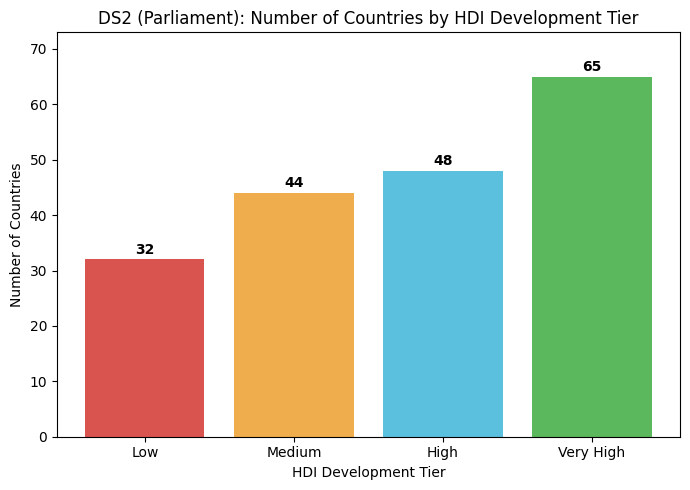

In [41]:
tier_order = ['Low', 'Medium', 'High', 'Very High']

ds2_tier_counts = (table.drop_duplicates('Country Code')['hdicode']
                   .value_counts()
                   .reindex(tier_order, fill_value=0))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(tier_order, ds2_tier_counts.values, color=['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c'])
ax.set_title('DS2 (Parliament): Number of Countries by HDI Development Tier')
ax.set_xlabel('HDI Development Tier')
ax.set_ylabel('Number of Countries')
ax.set_ylim(0, ds2_tier_counts.max() + 8)
for bar, count in zip(bars, ds2_tier_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(count),
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Enriching DS3 with HDI Classification

The same `hdi_lookup` is applied to the Ministerial dataset. The 4 unmatched countries (`MCO`, `NRU`, `PRK`, `SOM`) receive `NaN` here as well, consistent with DS2.

In [42]:
# Enrich DS3 (Ministerial)
df_proportion = df_proportion.merge(hdi_lookup, left_on='Country Code', right_on='iso3', how='left').drop(columns='iso3')

print("DS3 hdicode distribution (unique countries):")
print(df_proportion.drop_duplicates('Country Code')['hdicode'].value_counts(dropna=False))

DS3 hdicode distribution (unique countries):
hdicode
Very High    65
High         48
Medium       44
Low          32
NaN           4
Name: count, dtype: int64


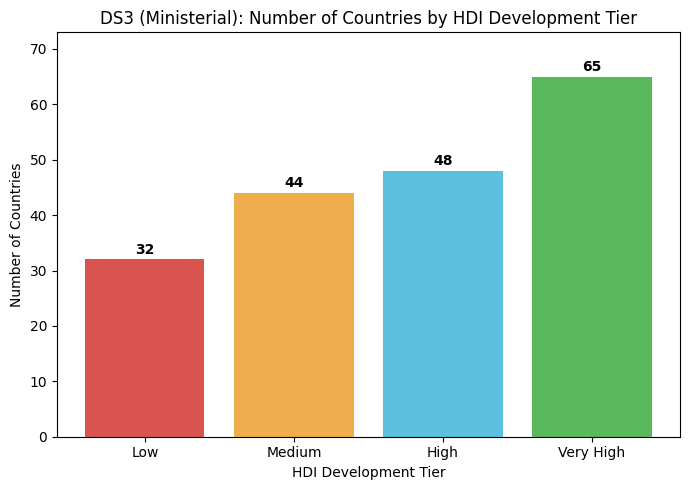

In [43]:
ds3_tier_counts = (df_proportion.drop_duplicates('Country Code')['hdicode']
                   .value_counts()
                   .reindex(tier_order, fill_value=0))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(tier_order, ds3_tier_counts.values, color=['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c'])
ax.set_title('DS3 (Ministerial): Number of Countries by HDI Development Tier')
ax.set_xlabel('HDI Development Tier')
ax.set_ylabel('Number of Countries')
ax.set_ylim(0, ds3_tier_counts.max() + 8)
for bar, count in zip(bars, ds3_tier_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(count),
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 8: Building the Female Political Representation Index (FPRI)

### What FPRI Measures

The **Female Political Representation Index (FPRI)** is a composite indicator that quantifies the degree to which women hold meaningful political power in a given country and year. It combines two complementary dimensions:

- **Legislative presence** (DS2): the percentage of parliamentary seats held by women — reflecting how well women are represented in the body that writes laws
- **Executive authority** (DS3): the percentage of ministerial-level positions held by women — reflecting how well women are represented in the body that drives policy, controls budgets, and governs directly

Neither dimension alone is sufficient. A country with many women in parliament but almost none in cabinet positions may have symbolic representation without real policy influence. Conversely, a small ministerial cohort with few parliamentarians lacks democratic legitimacy. FPRI captures both simultaneously, per country per year.

### Formula

$$\text{FPRI} = \sqrt{\text{parliment}\% \times \text{ministerial}\%}$$

### Why the Geometric Mean

The geometric mean is the same aggregation method used by the UNDP to combine the three dimensions of the Human Development Index — making FPRI methodologically consistent with DS1. Its defining property is that it **penalises imbalance**: a country scoring 40% in parliament but only 5% in ministerial positions yields an FPRI of ~14, far lower than the arithmetic average of 22.5. This reflects the view that genuine, impactful representation requires simultaneous presence in both legislative and executive roles — not strength in one compensating for weakness in the other.

### Granularity and Missing Data

FPRI is computed at the **country-year** level. The two datasets are joined on `Country Code` and `Year` using an inner join, so any country-year pair where either the parliament or ministerial percentage is absent is naturally excluded from the index — no imputation is applied.

In [44]:
# DS3 Year is datetime64 — extract integer year for joining
df_proportion_join = df_proportion.copy()
df_proportion_join['Year'] = df_proportion_join['Year'].dt.year

# Inner join on Country Code + Year (only rows present in both datasets are kept)
df_fpri = (
    table[['Country Name', 'Country Code', 'Year', 'Value', 'hdicode']]
    .rename(columns={'Value': 'parliament_pct'})
    .merge(
        df_proportion_join[['Country Code', 'Year', 'Value']].rename(columns={'Value': 'ministerial_pct'}),
        on=['Country Code', 'Year'],
        how='inner'
    )
)

print(f"FPRI dataset: {df_fpri['Country Code'].nunique()} countries × {df_fpri['Year'].nunique()} years = {len(df_fpri)} records")

FPRI dataset: 193 countries × 13 years = 2387 records


In [45]:
# Compute FPRI using the geometric mean of the two normalised percentages
df_fpri['FPRI'] = 100 * np.sqrt((df_fpri['parliament_pct'] / 100) * (df_fpri['ministerial_pct'] / 100))

print(f"FPRI range:   {df_fpri['FPRI'].min():.2f} – {df_fpri['FPRI'].max():.2f}")
print(f"Global mean FPRI: {df_fpri['FPRI'].mean():.2f}")
print(f"Records with NaN FPRI: {df_fpri['FPRI'].isna().sum()}")

df_fpri[['Country Name', 'Country Code', 'Year', 'parliament_pct', 'ministerial_pct', 'hdicode', 'FPRI']].head(15)

FPRI range:   0.00 – 58.83
Global mean FPRI: 19.47
Records with NaN FPRI: 0


,Country Name,Country Code,Year,parliament_pct,ministerial_pct,hdicode,FPRI
0,Afghanistan,AFG,2020,27.016,6.452,Low,13.202546
1,Afghanistan,AFG,2019,27.869,9.677,Low,16.422190
2,Afghanistan,AFG,2016,27.711,16.700,Low,21.512176
3,Afghanistan,AFG,2015,27.711,10.000,Low,16.646621
4,Afghanistan,AFG,2014,27.711,11.100,Low,17.538304
5,Afghanistan,AFG,2012,27.711,12.000,Low,18.235460
6,Afghanistan,AFG,2010,27.711,7.400,Low,14.319965
7,Afghanistan,AFG,2008,27.686,3.700,Low,10.121176
8,Afghanistan,AFG,2005,27.309,10.000,Low,16.525435
9,Albania,ALB,2024,35.714,41.667,High,38.575837


## Section 9: Data Integration — Three-Way Temporal Alignment

**Nature: Data Integration**

`df_fpri` currently spans 13 years (2005–2024, irregular), but DS1 (HDR21) only provides HDI values up to 2021. Since the master analytical dataset will require all three sources (FPRI (DS2+DS3), HDI level (DS1), and HDI growth (derived from DS1)) to be present for every record, `df_fpri` must be restricted to the years that DS1 can also supply.

The three-way overlap reduces the FPRI dataset from 13 years to **10 years**: 2005, 2008, 2010, 2012, 2014, 2015, 2016, 2018, 2019, 2020. The three post-2021 years (2022, 2023, 2024) are dropped.

In [46]:
ds1_years = set(df_hdr_final['Year'].unique())
fpri_years_available = set(df_fpri['Year'].unique())
overlap_years_3way = sorted(ds1_years & fpri_years_available)
dropped_years = sorted(fpri_years_available - ds1_years)

df_fpri = df_fpri[df_fpri['Year'].isin(overlap_years_3way)]

print(f"Three-way overlap years ({len(overlap_years_3way)}): {overlap_years_3way}")
print(f"Dropped from df_fpri (no DS1 match): {dropped_years}")
print(f"df_fpri after alignment: {df_fpri['Country Code'].nunique()} countries \u00d7 {df_fpri['Year'].nunique()} years = {len(df_fpri)} records")

Three-way overlap years (10): [np.int64(2005), np.int64(2008), np.int64(2010), np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2018), np.int64(2019), np.int64(2020)]
Dropped from df_fpri (no DS1 match): [np.int64(2022), np.int64(2023), np.int64(2024)]
df_fpri after alignment: 193 countries × 10 years = 1835 records


## Section 10: Data Enrichment — HDI Year-on-Year Growth Rate


The project hypothesis concerns the relationship between female political representation and **HDI growth**, not the absolute HDI level. Hence year-on-year (YoY) growth rate is computed for each country across all years available in DS1 (2005–2021) using the standard percentage-change formula:

$$\text{HDI\_growth}_t = \frac{\text{HDI}_t - \text{HDI}_{t-1}}{\text{HDI}_{t-1}} \times 100$$

This is computed over the full DS1 range (not just the 10 FPRI-aligned years), so that the growth rate for each aligned year is calculated against the correct prior-year HDI value. The master join in Section 11 then naturally selects only the aligned years. The first observation per country has no prior year and will be `NaN`; these rows are handled in Section 11.

In [47]:
df_hdr_final = df_hdr_final.sort_values(['iso3', 'Year'])
df_hdr_final['HDI_growth'] = df_hdr_final.groupby('iso3')['HDI'].pct_change() * 100

nan_growth = df_hdr_final['HDI_growth'].isna().sum()
print(f"HDI_growth NaN (first year per country, expected ~{df_hdr_final['iso3'].nunique()}): {nan_growth}")
print()
print(df_hdr_final[['country', 'iso3', 'Year', 'HDI', 'HDI_growth']].dropna().head(10).to_string(index=False))

HDI_growth NaN (first year per country, expected ~195): 290

    country iso3  Year   HDI  HDI_growth
Afghanistan  AFG  2006 0.409    2.250000
Afghanistan  AFG  2007 0.424    3.667482
Afghanistan  AFG  2008 0.430    1.415094
Afghanistan  AFG  2009 0.440    2.325581
Afghanistan  AFG  2010 0.448    1.818182
Afghanistan  AFG  2011 0.456    1.785714
Afghanistan  AFG  2012 0.466    2.192982
Afghanistan  AFG  2013 0.474    1.716738
Afghanistan  AFG  2014 0.479    1.054852
Afghanistan  AFG  2015 0.478   -0.208768


C:\Users\Gu Xinyi\AppData\Local\Temp\ipykernel_25348\2604840011.py:2: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_hdr_final['HDI_growth'] = df_hdr_final.groupby('iso3')['HDI'].pct_change() * 100


## Section 11: Master Analytical Dataset

This section assembles the single dataset used for all downstream analysis by joining `df_fpri` (193 countries × 10 years) with `df_hdr_final` (HDI level + HDI growth) on `Country Code` / `iso3` and `Year`.

An inner join ensures only records with a match in both sources are retained. After joining, rows where `HDI` or `HDI_growth` is `NaN` are dropped — these correspond to countries with sparse early-year coverage in DS1 (e.g. newly formed states with no 2004 baseline for growth computation). This is a deliberate **data cleaning** step: including NaN growth rows would silently distort any correlation or regression analysis.

**Final schema of `df_master`:**

| Column | Source | Description |
|---|---|---|
| `Country Name` | DS2 | Full country name |
| `Country Code` | DS2/DS3 | ISO 3166-1 alpha-3 |
| `Year` | DS2/DS3 | Reporting year |
| `parliament_pct` | DS2 | % women in parliament |
| `ministerial_pct` | DS3 | % women in ministerial positions |
| `FPRI` | Derived | Female Political Representation Index (geometric mean) |
| `hdicode` | DS1 | HDI development tier (Low / Medium / High / Very High) |
| `HDI` | DS1 | Human Development Index score |
| `HDI_growth` | Derived | YoY % change in HDI |

In [48]:
df_master = df_fpri.merge(
    df_hdr_final[['iso3', 'Year', 'HDI', 'HDI_growth']],
    left_on=['Country Code', 'Year'],
    right_on=['iso3', 'Year'],
    how='inner'
).drop(columns='iso3')

before = len(df_master)
df_master = df_master.dropna(subset=['HDI', 'HDI_growth'])

print(f"Master dataset: {before} \u2192 {len(df_master)} records after dropping NaN HDI/growth rows")
print(f"Countries: {df_master['Country Code'].nunique()}, Years: {sorted(df_master['Year'].unique())}")
print(f"Columns: {list(df_master.columns)}")

Master dataset: 1835 → 1620 records after dropping NaN HDI/growth rows
Countries: 189, Years: [np.int64(2008), np.int64(2010), np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2018), np.int64(2019), np.int64(2020)]
Columns: ['Country Name', 'Country Code', 'Year', 'parliament_pct', 'hdicode', 'ministerial_pct', 'FPRI', 'HDI', 'HDI_growth']


In [49]:
df_master[['Country Name', 'Country Code', 'Year', 'parliament_pct', 'ministerial_pct', 'FPRI', 'HDI', 'HDI_growth', 'hdicode']].head(15)

,Country Name,Country Code,Year,parliament_pct,ministerial_pct,FPRI,HDI,HDI_growth,hdicode
0,Afghanistan,AFG,2020,27.016,6.452,13.202546,0.483,-1.024590,Low
1,Afghanistan,AFG,2019,27.869,9.677,16.422190,0.488,1.035197,Low
2,Afghanistan,AFG,2016,27.711,16.700,21.512176,0.481,0.627615,Low
3,Afghanistan,AFG,2015,27.711,10.000,16.646621,0.478,-0.208768,Low
4,Afghanistan,AFG,2014,27.711,11.100,17.538304,0.479,1.054852,Low
5,Afghanistan,AFG,2012,27.711,12.000,18.235460,0.466,2.192982,Low
6,Afghanistan,AFG,2010,27.711,7.400,14.319965,0.448,1.818182,Low
7,Afghanistan,AFG,2008,27.686,3.700,10.121176,0.430,1.415094,Low
9,Albania,ALB,2020,29.508,56.250,40.740950,0.794,-1.975309,High
10,Albania,ALB,2019,29.508,53.333,39.670520,0.810,0.496278,High


## Section 12: Data Profiling — HDI Tier Balance and Confounding Risk

**Nature: Data Profiling**

Before running any correlation analysis, the issue of over-representation and two questions must be answered about the composition of `df_master`:

1. **Is any HDI tier over-represented?** If one development group dominates the record count, the global correlation will disproportionately reflect that group's patterns rather than a universal relationship.

2. **Is HDI tier itself a confounder?** Even with a balanced distribution, because of the introduction of HDI tiering to woman representation datasets, both FPRI and HDI growth are now influenced by HDI tier. Hence the global correlation could be corrupted if: 
(a) mean FPRI differs across tiers 
(b) mean HDI growth also differs across tiers 

because then any observed FPRI–HDI growth relationship may simply reflect the shared dependence on development level, not a causal link.

The table and charts below show that the sample distribution is reasonably close to the global distribution (Very High HDI is modestly over-represented at 34% vs 30% globally; Low HDI is modestly under-represented at 17% vs 22%). There is no severe sampling bias.

However, the right-hand chart exposes a clear confound: mean annual HDI growth declines sharply from Low (~0.84%/yr) to Very High (~0.33%/yr) HDI tiers. Since Very High HDI countries also happen to have the highest mean FPRI, a global correlation would produce a misleadingly negative signal where HDI grows very slowly not because FPRI suppresses growth, but because already-developed countries naturally grow more slowly. **The analysis in Section 13 therefore stratifies by tier to isolate the within-group relationship.**

In [50]:
tier_order = ['Low', 'Medium', 'High', 'Very High']

summary = df_master.groupby('hdicode').agg(
    Countries=('Country Code', 'nunique'),
    Records=('Country Code', 'count'),
    Mean_FPRI=('FPRI', 'mean'),
    Mean_HDI_growth=('HDI_growth', 'mean')
).reindex(tier_order).round(2)

summary['%Countries'] = (summary['Countries'] / summary['Countries'].sum() * 100).round(1)

print(summary[['Countries', '%Countries', 'Records', 'Mean_FPRI', 'Mean_HDI_growth']])

           Countries  %Countries  Records  Mean_FPRI  Mean_HDI_growth
hdicode                                                              
Low               32        16.9      262      19.06             0.84
Medium            44        23.3      377      15.50             0.70
High              48        25.4      412      17.04             0.39
Very High         65        34.4      569      22.32             0.33


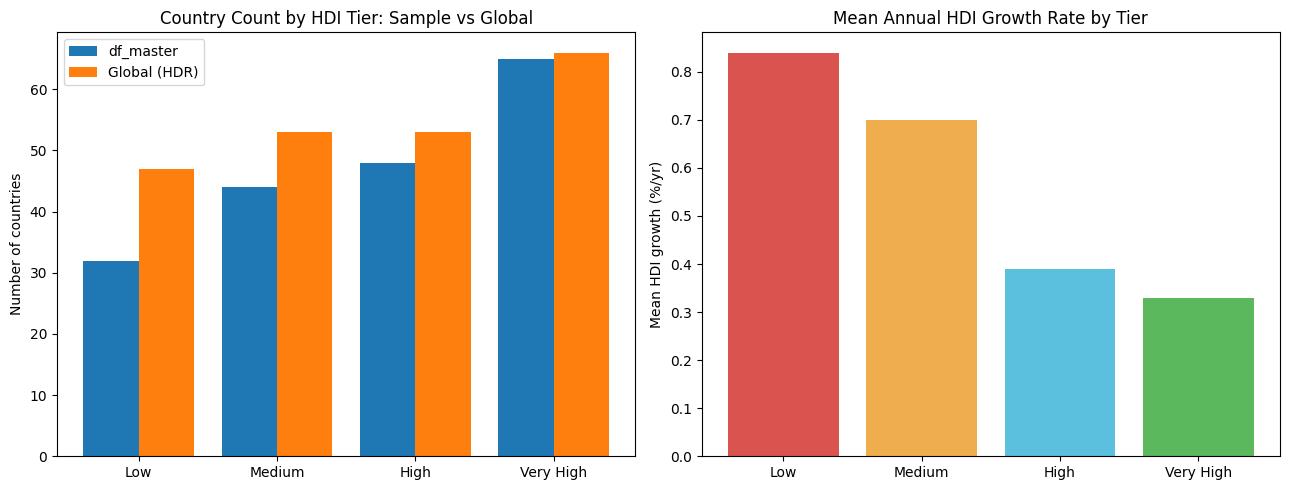

In [51]:
global_counts = {'Low': 47, 'Medium': 53, 'High': 53, 'Very High': 66}
x = range(len(tier_order))
sample_counts = [summary.loc[t, 'Countries'] for t in tier_order]
global_vals   = [global_counts[t] for t in tier_order]
growth_vals   = [summary.loc[t, 'Mean_HDI_growth'] for t in tier_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar([i - 0.2 for i in x], sample_counts, width=0.4, label='df_master')
axes[0].bar([i + 0.2 for i in x], global_vals,   width=0.4, label='Global (HDR)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(tier_order)
axes[0].set_ylabel('Number of countries')
axes[0].set_title('Country Count by HDI Tier: Sample vs Global')
axes[0].legend()

axes[1].bar(tier_order, growth_vals, color=['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c'])
axes[1].set_title('Mean Annual HDI Growth Rate by Tier')
axes[1].set_ylabel('Mean HDI growth (%/yr)')

plt.tight_layout()
plt.show()

### Zero-FPRI Records: Distribution and Root Cause

**Nature: Data Profiling**

Because FPRI uses a geometric mean, it collapses to zero whenever either the parliament percentage or the ministerial percentage is zero — regardless of how high the other dimension is. The chart below profiles how many such zero-FPRI records exist within each development tier, and which component (parliament or ministerial) was responsible.

This breakdown matters for two reasons. First, it shows where data sparsity is concentrated — Medium HDI countries account for the highest share of zeros (11.1% of their records). Second, it sets up the robustness check in Section 14: if the correlation results from Section 13 were being driven by these zero-FPRI outliers rather than the main distribution, excluding them should substantially change the Spearman rho values.

           Total  Zero FPRI  % Zero  Parliament=0  Ministerial=0
Tier                                                            
Low          262          8     3.1             3              5
Medium       377         42    11.1            25             32
High         412         28     6.8             9             22
Very High    569         34     6.0            11             28


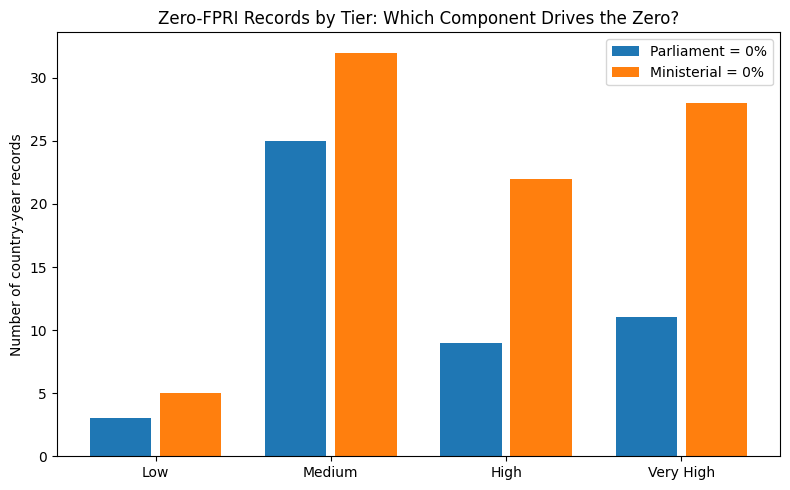

In [54]:
zero_counts = []
for tier in tier_order:
    sub = df_master[df_master['hdicode'] == tier]
    zeros = sub[sub['FPRI'] == 0]
    zero_counts.append({
        'Tier': tier,
        'Total': len(sub),
        'Zero FPRI': len(zeros),
        '% Zero': round(len(zeros) / len(sub) * 100, 1),
        'Parliament=0': (zeros['parliament_pct'] == 0).sum(),
        'Ministerial=0': (zeros['ministerial_pct'] == 0).sum(),
    })
zero_df = pd.DataFrame(zero_counts).set_index('Tier')
print(zero_df)

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(tier_order))
ax.bar([i - 0.2 for i in x], zero_df['Parliament=0'], width=0.35, label='Parliament = 0%')
ax.bar([i + 0.2 for i in x], zero_df['Ministerial=0'], width=0.35, label='Ministerial = 0%')
ax.set_xticks(list(x))
ax.set_xticklabels(tier_order)
ax.set_ylabel('Number of country-year records')
ax.set_title('Zero-FPRI Records by Tier: Which Component Drives the Zero?')
ax.legend()
plt.tight_layout()
plt.show()

## Section 13: Analysis — Stratified FPRI vs HDI Growth Correlation

This section tests the core hypothesis: *does higher female political representation (FPRI) correlate with stronger HDI growth?*

**Measure of association:** We use **Spearman's rank correlation** (ρ) rather than Pearson's *r*. Spearman assesses **monotonic** association (whether higher FPRI ranks tend to pair with higher or lower HDI-growth ranks) and does **not** assume a straight-line relationship. It is also **less sensitive to outliers** in HDI growth, which can be volatile year-to-year. Pearson would be the default if we were confident the relationship were strictly linear with roughly homoscedastic residuals; those assumptions are doubtful here, so Spearman is a better match for the research question.

**Why stratify?** As established in Section 12, running a single global Spearman correlation would conflate two effects: (1) the true within-tier FPRI–growth relationship, and (2) the across-tier pattern where already-developed (Very High HDI) countries have both high FPRI and low growth purely because of their development ceiling. Stratification by HDI tier holds development level constant, so the correlation within each group reflects a more credible signal.

**Interpretation guide:**
- A **positive ρ** within a tier means higher FPRI ranks tend to align with higher HDI-growth ranks (a monotonic pattern) — consistent with the hypothesis.
- A **negative ρ** means the opposite ranking pattern, or that other within-tier factors dominate.
- **p-value < 0.05** indicates the rank correlation is statistically significant at the 5% level (see Section 15 for independence caveats).
- The **unstratified (All)** row is included as a reference — its value is expected to be negative or near zero due to the confound, illustrating why stratification is necessary.

**Plots:** Each panel shows a scatter of raw FPRI vs HDI growth. The **black line** is an **OLS linear fit** for visual orientation only; the statistic in the title is **Spearman ρ**, which does not assume linearity.

In [ ]:
from scipy import stats

rows = []
for tier in tier_order:
    sub = df_master[df_master['hdicode'] == tier].dropna(subset=['FPRI', 'HDI_growth'])
    rho, p = stats.spearmanr(sub['FPRI'], sub['HDI_growth'])
    rows.append({'Tier': tier, 'n': len(sub), 'Spearman rho': round(rho, 3), 'p-value': round(p, 4)})

overall = df_master.dropna(subset=['FPRI', 'HDI_growth'])
rho_all, p_all = stats.spearmanr(overall['FPRI'], overall['HDI_growth'])
rows.append({'Tier': 'All (unstratified)', 'n': len(overall), 'Spearman rho': round(rho_all, 3), 'p-value': round(p_all, 4)})

corr_table = pd.DataFrame(rows).set_index('Tier')
print(corr_table)

In [ ]:
colors = {'Low': '#d9534f', 'Medium': '#f0ad4e', 'High': '#5bc0de', 'Very High': '#5cb85c'}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, tier in enumerate(tier_order):
    sub = df_master[df_master['hdicode'] == tier].dropna(subset=['FPRI', 'HDI_growth'])
    ax = axes[i]
    ax.scatter(sub['FPRI'], sub['HDI_growth'], alpha=0.4, color=colors[tier], s=20)
    m, b = np.polyfit(sub['FPRI'], sub['HDI_growth'], 1)
    xline = np.linspace(sub['FPRI'].min(), sub['FPRI'].max(), 100)
    ax.plot(xline, m * xline + b, color='black', linewidth=1.2)
    rho = corr_table.loc[tier, 'Spearman rho']
    p = corr_table.loc[tier, 'p-value']
    ax.set_title(f'{tier} HDI  (rho = {rho}, p = {p})')
    ax.set_xlabel('FPRI')
    ax.set_ylabel('HDI growth (%/yr)')

plt.suptitle('FPRI vs HDI Growth by Tier (Spearman rho; OLS line for display)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Section 14: Robustness Check — Excluding Zero-FPRI Records

**Nature: Data Analysis (Robustness Check)**

The 112 zero-FPRI records identified in Section 12 are real observations, not missing data — they represent country-years where women held literally 0% of parliamentary seats or 0% of ministerial positions. However, all 112 points sit at exactly FPRI = 0 on the x-axis of every scatter plot, creating a dense spike at the left edge that can pull the OLS regression line and distort the reported Spearman ρ.

This section re-runs the stratified **Spearman** correlation from Section 13 on `df_master[df_master['FPRI'] > 0]` to test whether the Section 13 results are an artefact of those extreme values or hold across the broader distribution.

**Key finding:** Removing zero-FPRI records makes the overall association **more** negative (global ρ moves from about −0.13 to −0.17). The Very High HDI signal remains strongly negative (ρ ≈ −0.27, p < 0.001). Medium HDI shows a weak negative rank correlation when zeros are excluded (ρ ≈ −0.12, p < 0.05); High HDI shows a similar direction but **does not** reach significance at 5% under Spearman once zeros are removed. This confirms that the Section 13 conclusions are robust — there is still no evidence of a positive FPRI–HDI growth relationship.

In [ ]:
from scipy import stats

df_nonzero = df_master[df_master['FPRI'] > 0]
print(f"df_master (all):       {len(df_master)} records")
print(f"df_master (FPRI > 0):  {len(df_nonzero)} records  ({len(df_master) - len(df_nonzero)} zero-FPRI rows excluded)\n")

rows_robust = []
for tier in tier_order:
    sub_all     = df_master[df_master['hdicode'] == tier].dropna(subset=['FPRI', 'HDI_growth'])
    sub_nonzero = df_nonzero[df_nonzero['hdicode'] == tier].dropna(subset=['FPRI', 'HDI_growth'])
    rho_orig,   p_orig  = stats.spearmanr(sub_all['FPRI'],     sub_all['HDI_growth'])
    rho_robust, p_rob   = stats.spearmanr(sub_nonzero['FPRI'], sub_nonzero['HDI_growth'])
    rows_robust.append({
        'Tier':          tier,
        'rho (all)':     round(rho_orig, 3),
        'p (all)':       round(p_orig, 4),
        'rho (FPRI>0)':  round(rho_robust, 3),
        'p (FPRI>0)':    round(p_rob, 4),
    })

robust_table = pd.DataFrame(rows_robust).set_index('Tier')
print(robust_table)

In [ ]:
colors = {'Low': '#d9534f', 'Medium': '#f0ad4e', 'High': '#5bc0de', 'Very High': '#5cb85c'}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, tier in enumerate(tier_order):
    sub = df_nonzero[df_nonzero['hdicode'] == tier].dropna(subset=['FPRI', 'HDI_growth'])
    ax = axes[i]
    ax.scatter(sub['FPRI'], sub['HDI_growth'], alpha=0.4, color=colors[tier], s=20)
    m, b = np.polyfit(sub['FPRI'], sub['HDI_growth'], 1)
    xline = np.linspace(sub['FPRI'].min(), sub['FPRI'].max(), 100)
    ax.plot(xline, m * xline + b, color='black', linewidth=1.2)
    rho = robust_table.loc[tier, 'rho (FPRI>0)']
    p = robust_table.loc[tier, 'p (FPRI>0)']
    ax.set_title(f'{tier} HDI  (rho = {rho}, p = {p})')
    ax.set_xlabel('FPRI')
    ax.set_ylabel('HDI growth (%/yr)')

plt.suptitle('Robustness: FPRI vs HDI Growth, FPRI > 0 only (Spearman rho; OLS line for display)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Section 15: Conclusions

### Central Question
*Does higher female political representation (as measured by the FPRI) correlate with stronger HDI growth?*

---

### Summary of Findings

The evidence from this analysis does **not** support the hypothesis. No development tier shows a statistically significant **positive** Spearman association between FPRI and HDI growth. The full picture across Sections 13 and 14 (Spearman ρ) is:

| Tier | rho (all records) | Significant? | rho (FPRI > 0) | Significant? |
|---|---|---|---|---|
| Low HDI | -0.023 | No | -0.051 | No |
| Medium HDI | -0.038 | No | -0.122 | Yes (*) |
| High HDI | -0.010 | No | -0.075 | No |
| Very High HDI | -0.271 | Yes (***) | -0.271 | Yes (***) |
| All (unstratified) | -0.125 | Yes (***) | -0.170 | Yes (***) |

---

### Interpretation

**Low HDI countries:** No meaningful rank association in either direction (rho near zero, non-significant). Within this group, variation in female representation does not co-vary monotonically with variation in HDI growth.

**Medium HDI countries:** The full-dataset Spearman correlation is near zero and non-significant, but excluding zero-FPRI records reveals a weak negative rank association (rho ≈ −0.12, p < 0.05).

**High HDI countries:** Spearman rho stays near zero for the full sample and remains **non-significant** after excluding zero-FPRI rows (rho ≈ −0.08, p > 0.14). Under this rank-based measure, there is no statistically reliable within-tier negative association for High HDI.

**Very High HDI countries:** The most statistically robust finding — a consistent negative Spearman correlation (rho ≈ −0.27, p < 0.001) that is unchanged by the zero-FPRI exclusion. The most plausible explanation is a **ceiling effect**: countries already near the HDI maximum have limited scope for growth regardless of their FPRI level. Within this tier, the countries with the highest FPRI (notably Nordic states) are also the ones nearest the HDI ceiling and therefore show the smallest year-on-year gains.

**Unstratified result:** Global rho is about −0.13 to −0.17 depending on whether zeros are included — statistically significant but substantively moderate. As Section 12 established, this signal is partly a confound — Very High HDI countries simultaneously dominate FPRI scores and show the lowest growth, not because of their representation but because of their development ceiling.

---

### Limitations

1. **Correlation ≠ causation.** A positive association, had it been found, would not establish that representation *causes* HDI growth. Equally, the negative/null results here do not rule out a causal effect that operates over longer time horizons or through channels not captured by annual HDI scores.

2. **No lag structure.** The analysis compares FPRI and HDI growth in the same year. If representation has a delayed effect (e.g., legislative changes take years to translate into education or health outcomes), a contemporaneous correlation would understate it.

3. **Panel data autocorrelation.** The same country appears up to 10 times, so observations within a country are not independent. Spearman rho (like Pearson r) treats each row as independent when computing p-values, which inflates effective sample size. A fixed-effects panel model would be the appropriate next step.

4. **FPRI limitations.** The composite index captures only two formal dimensions of political representation and does not distinguish between token inclusion and substantive legislative influence.

---

### Final Statement

Based on the available data (193 countries, 10 irregular years between 2005 and 2020), **female political representation as measured by the FPRI is not positively associated with HDI growth at any development tier** under Spearman's rank correlation. The relationship is either absent (Low HDI) or negative in the Very High HDI tier; Medium HDI shows a weak negative signal only after excluding zero-FPRI observations. The most analytically defensible conclusion is that **the hypothesis is not supported by this dataset**, while acknowledging that a causal relationship may exist through mechanisms and time horizons that simple cross-sectional rank correlation is not designed to detect.